<a href="https://colab.research.google.com/github/Kishanmvs/Machine-Learning-II-Lab-BCI702/blob/main/Lab1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis — Solar Flares Dataset

**Prerequisite (pre-Module 1):** Foundational data handling with NumPy, Pandas, and Matplotlib.

This notebook covers:
1. Loading the dataset (via `kagglehub`)
2. Data cleaning (handling missing values)
3. Summary statistics
4. Distribution plots
5. Correlation analysis


## 1. Imports

In [1]:
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Nicer default plot style
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 50)


## 2. Download and Load the Dataset

In [2]:
# Download latest version of the dataset from Kaggle
path = kagglehub.dataset_download("stealthtechnologies/solar-flares-dataset")
print("Path to dataset files:", path)

# List files in the downloaded folder
files = os.listdir(path)
print("Files found:", files)


100%|██████████| 4.21k/4.21k [00:00<00:00, 6.23MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/stealthtechnologies/solar-flares-dataset/versions/3
Files found: ['data.csv']


In [3]:
# Load the first CSV file found in the dataset folder
csv_files = [f for f in files if f.endswith('.csv')]
print("CSV files:", csv_files)

file_path = os.path.join(path, csv_files[0])
df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()


CSV files: ['data.csv']
Shape: (1389, 13)


,modified Zurich class,largest spot size,spot distribution,activity,evolution,previous 24 hour flare activity,historically-complex,became complex on this pass,area,area of largest spot,common flares,moderate flares,severe flares
0,C,S,O,1,2,1,1,2,1,2,0,0,0
1,D,S,O,1,3,1,1,2,1,2,0,0,0
2,C,S,O,1,3,1,1,2,1,1,0,0,0
3,D,S,O,1,3,1,1,2,1,2,0,0,0
4,D,A,O,1,3,1,1,2,1,2,0,0,0


## 3. Initial Data Overview

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   modified Zurich class            1389 non-null   object
 1   largest spot size                1389 non-null   object
 2   spot distribution                1389 non-null   object
 3   activity                         1389 non-null   int64 
 4   evolution                        1389 non-null   int64 
 5   previous 24 hour flare activity  1389 non-null   int64 
 6   historically-complex             1389 non-null   int64 
 7   became complex on this pass      1389 non-null   int64 
 8   area                             1389 non-null   int64 
 9   area of largest spot             1389 non-null   int64 
 10  common flares                    1389 non-null   int64 
 11  moderate flares                  1389 non-null   int64 
 12  severe flares                    1

In [5]:
print("Number of duplicate rows:", df.duplicated().sum())
print("\nColumn data types:\n", df.dtypes)


Number of duplicate rows: 862

Column data types:
 modified Zurich class              object
largest spot size                  object
spot distribution                  object
activity                            int64
evolution                           int64
previous 24 hour flare activity     int64
historically-complex                int64
became complex on this pass         int64
area                                int64
area of largest spot                int64
common flares                       int64
moderate flares                     int64
severe flares                       int64
dtype: object


## 4. Handling Missing Values

In [6]:
# Count missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_df


,missing_count,missing_pct


In [7]:
# Visualize missing values
if len(missing_df) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(missing_df.index.astype(str), missing_df['missing_pct'])
    plt.xticks(rotation=90)
    plt.ylabel("% Missing")
    plt.title("Percentage of Missing Values per Column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")


No missing values found in the dataset.


In [8]:
# Cleaning strategy:
# - Drop columns with more than 50% missing values (too sparse to be useful)
# - Fill remaining numeric missing values with the column median
# - Fill remaining categorical/object missing values with the mode

threshold = 0.5
cols_to_drop = missing_df[missing_df['missing_pct'] > threshold * 100].index.tolist()
df_clean = df.drop(columns=cols_to_drop)
print("Dropped columns (>50% missing):", cols_to_drop)

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
categorical_cols = df_clean.select_dtypes(exclude=[np.number]).columns

for col in numeric_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_cols:
    if df_clean[col].isnull().any():
        mode_val = df_clean[col].mode()
        if not mode_val.empty:
            df_clean[col] = df_clean[col].fillna(mode_val[0])

print("\nRemaining missing values after cleaning:", df_clean.isnull().sum().sum())
df_clean.head()


Dropped columns (>50% missing): []

Remaining missing values after cleaning: 0


,modified Zurich class,largest spot size,spot distribution,activity,evolution,previous 24 hour flare activity,historically-complex,became complex on this pass,area,area of largest spot,common flares,moderate flares,severe flares
0,C,S,O,1,2,1,1,2,1,2,0,0,0
1,D,S,O,1,3,1,1,2,1,2,0,0,0
2,C,S,O,1,3,1,1,2,1,1,0,0,0
3,D,S,O,1,3,1,1,2,1,2,0,0,0
4,D,A,O,1,3,1,1,2,1,2,0,0,0


## 5. Summary Statistics

In [9]:
df_clean.describe().T


,count,mean,std,min,25%,50%,75%,max
activity,1389.0,1.150468,0.357658,1.0,1.0,1.0,1.0,2.0
evolution,1389.0,2.421166,0.617129,1.0,2.0,2.0,3.0,3.0
previous 24 hour flare activity,1389.0,1.089993,0.403292,1.0,1.0,1.0,1.0,3.0
historically-complex,1389.0,1.395968,0.489234,1.0,1.0,1.0,2.0,2.0
became complex on this pass,1389.0,1.892009,0.310481,1.0,2.0,2.0,2.0,2.0
area,1389.0,1.025918,0.158948,1.0,1.0,1.0,1.0,2.0
area of largest spot,1389.0,1.175666,0.380673,1.0,1.0,1.0,1.0,2.0
common flares,1389.0,0.261339,0.760201,0.0,0.0,0.0,0.0,8.0
moderate flares,1389.0,0.067675,0.353695,0.0,0.0,0.0,0.0,5.0
severe flares,1389.0,0.009359,0.103534,0.0,0.0,0.0,0.0,2.0


In [10]:
# Summary stats for categorical columns (if any remain)
if len(categorical_cols) > 0:
    display(df_clean[categorical_cols].describe().T)
else:
    print("No categorical columns present.")


,count,unique,top,freq
modified Zurich class,1389,6,H,396
largest spot size,1389,6,S,514
spot distribution,1389,4,O,627


## 6. Distribution Plots

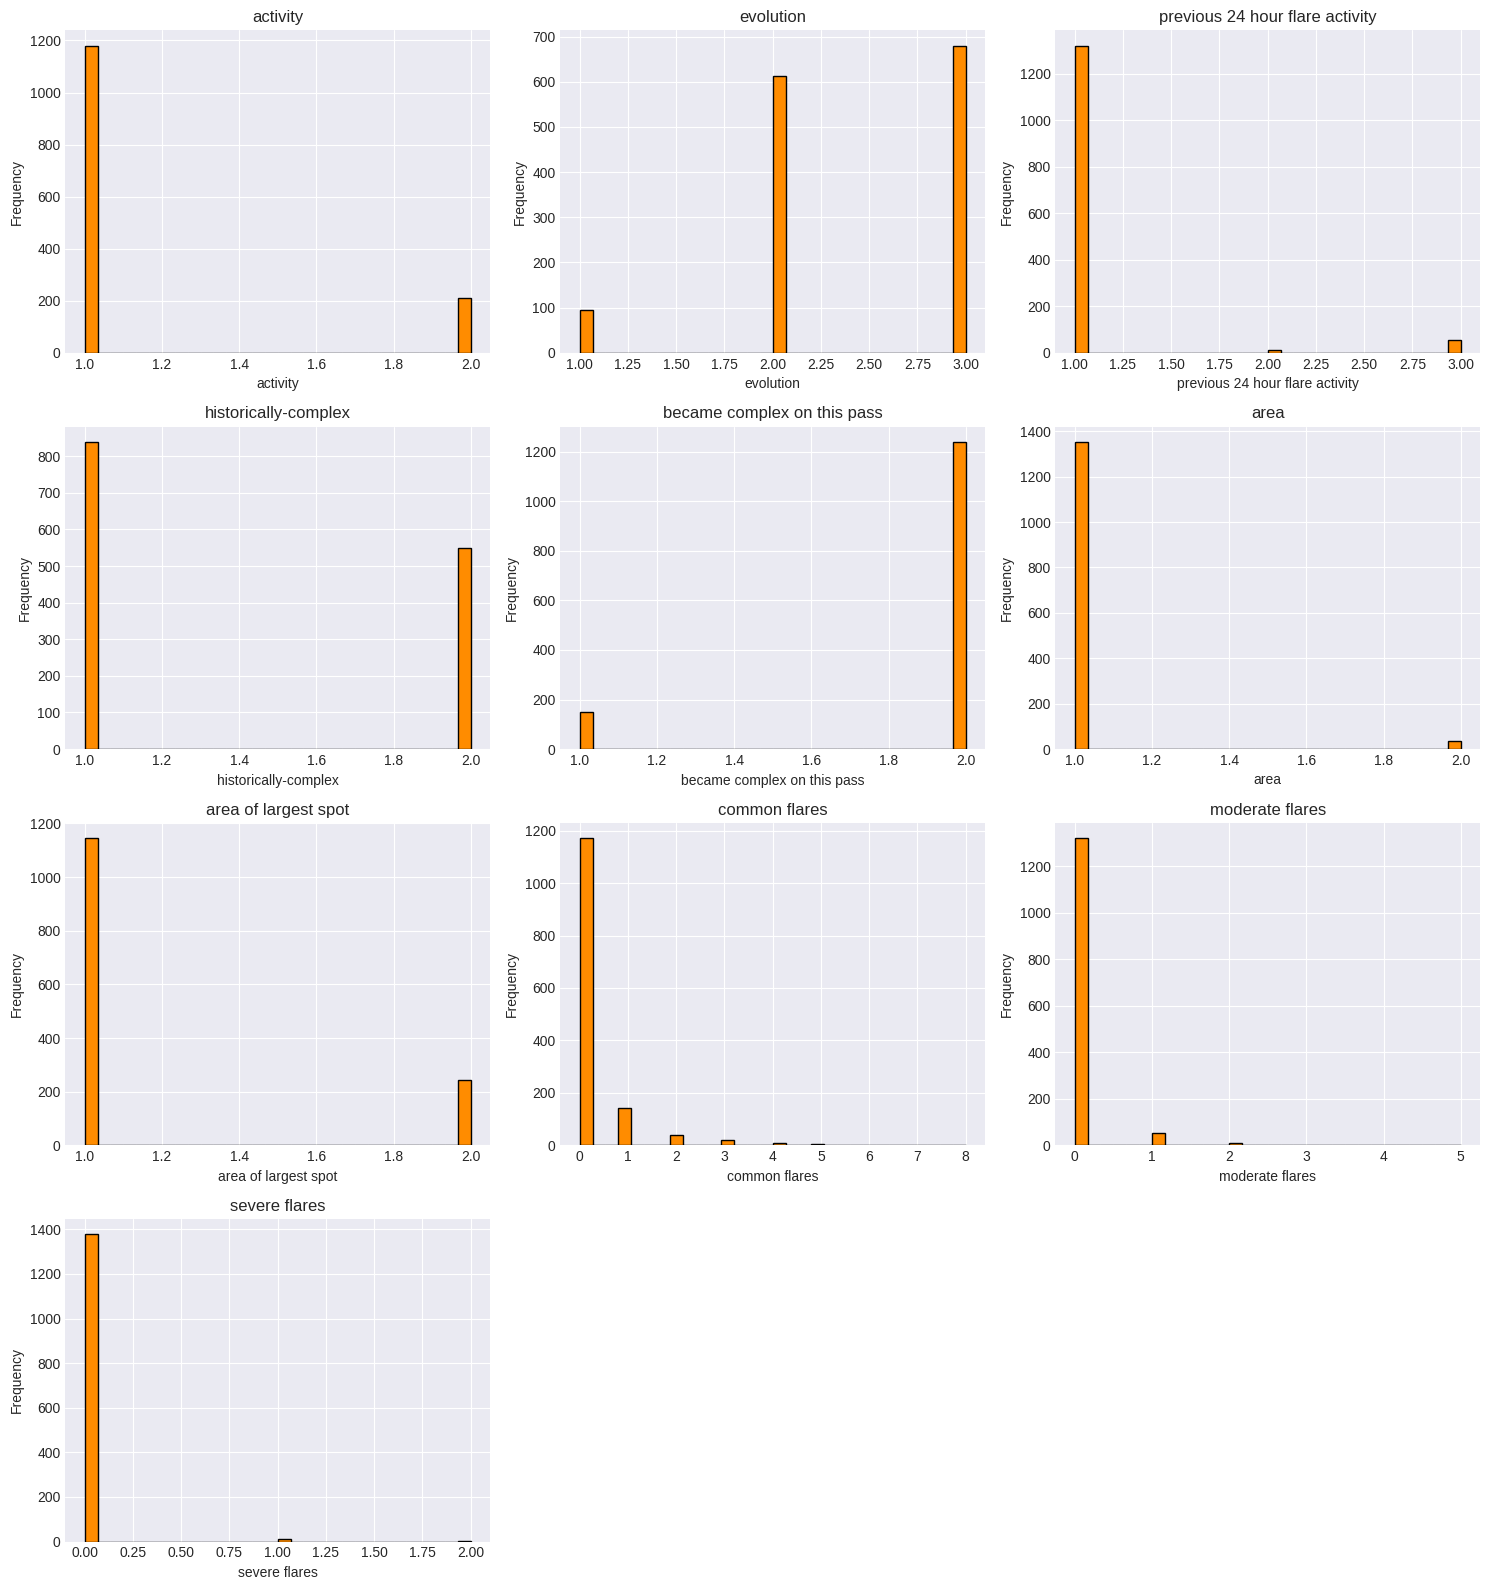

In [11]:
# Plot histograms for all numeric columns
num_cols = df_clean.select_dtypes(include=[np.number]).columns
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col].dropna(), bins=30, color='darkorange', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


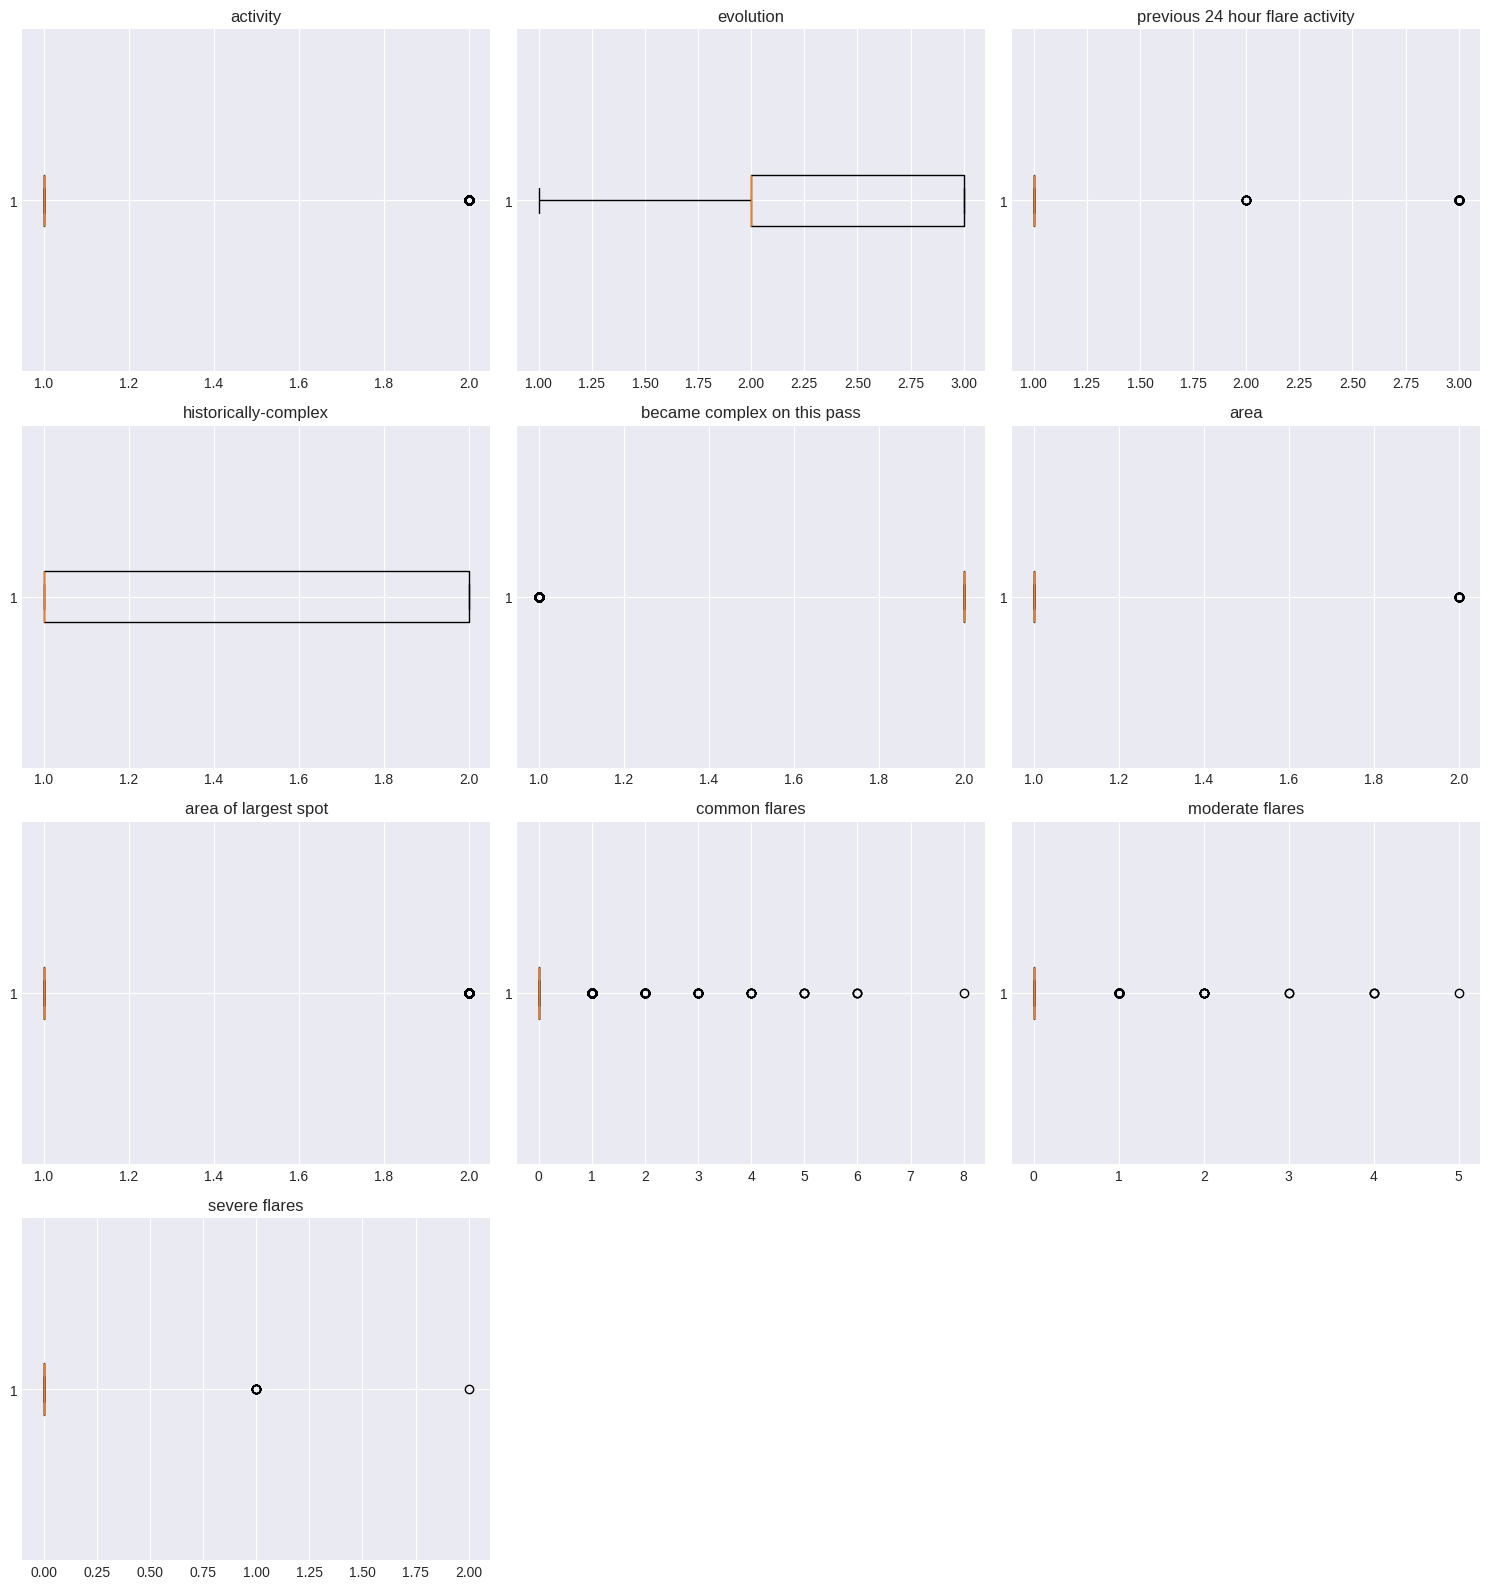

In [12]:
# Boxplots to inspect outliers for numeric columns
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.array(axes).flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df_clean[col].dropna(), vert=False)
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


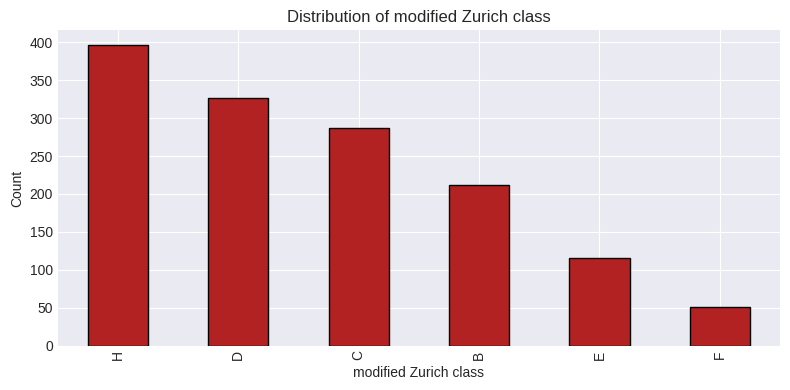

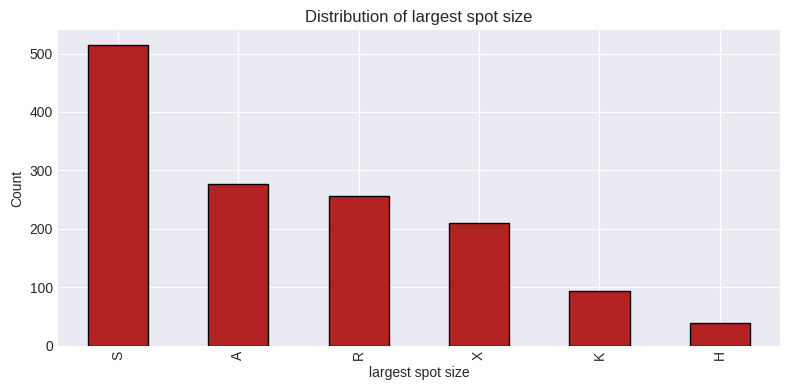

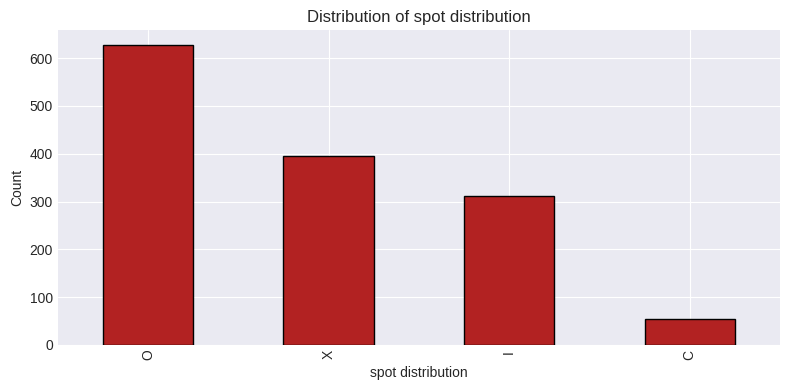

In [13]:
# If a categorical target/class column exists (e.g. flare class), show its distribution
if len(categorical_cols) > 0:
    for col in categorical_cols:
        plt.figure(figsize=(8, 4))
        df_clean[col].value_counts().plot(kind='bar', color='firebrick', edgecolor='black')
        plt.title(f"Distribution of {col}")
        plt.ylabel("Count")
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()


## 7. Correlation Analysis

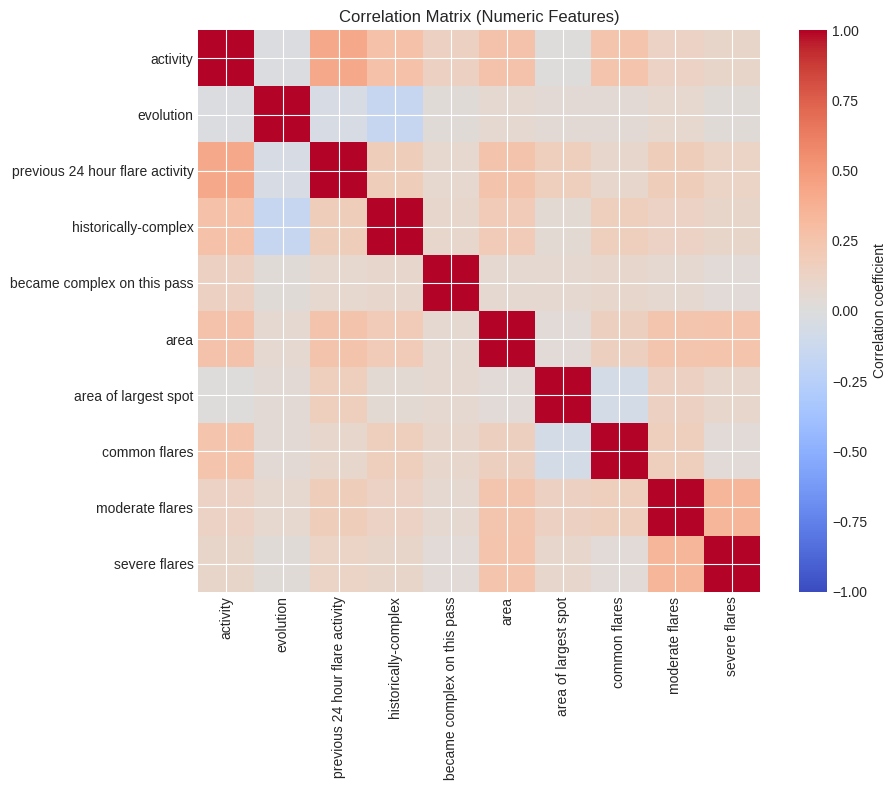

,activity,evolution,previous 24 hour flare activity,historically-complex,became complex on this pass,area,area of largest spot,common flares,moderate flares,severe flares
activity,1.000000,-0.016398,0.420524,0.268632,0.133458,0.260855,0.006804,0.244789,0.130171,0.098136
evolution,-0.016398,1.000000,-0.048186,-0.154251,0.030739,0.057569,0.040590,0.046250,0.077271,0.028470
previous 24 hour flare activity,0.420524,-0.048186,1.000000,0.173462,0.077670,0.255808,0.159754,0.092430,0.174459,0.117851
historically-complex,0.268632,-0.154251,0.173462,1.000000,0.087250,0.192201,0.051775,0.163232,0.128150,0.097466
became complex on this pass,0.133458,0.030739,0.077670,0.087250,1.000000,0.056756,0.063090,0.089134,0.060038,0.031465
area,0.260855,0.057569,0.255808,0.192201,0.056756,1.000000,0.031864,0.152591,0.237899,0.247928
area of largest spot,0.006804,0.040590,0.159754,0.051775,0.063090,0.031864,1.000000,-0.064149,0.136382,0.086215
common flares,0.244789,0.046250,0.092430,0.163232,0.089134,0.152591,-0.064149,1.000000,0.156574,0.032977
moderate flares,0.130171,0.077271,0.174459,0.128150,0.060038,0.237899,0.136382,0.156574,1.000000,0.336829
severe flares,0.098136,0.028470,0.117851,0.097466,0.031465,0.247928,0.086215,0.032977,0.336829,1.000000


In [14]:
corr = df_clean[num_cols].corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, label='Correlation coefficient')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

corr


In [15]:
# Top absolute correlations (excluding self-correlation)
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top_corr = corr_pairs.abs().sort_values(ascending=False).head(10)
print("Top 10 strongest correlations:")
top_corr


Top 10 strongest correlations:


activity                         previous 24 hour flare activity    0.420524
moderate flares                  severe flares                      0.336829
activity                         historically-complex               0.268632
                                 area                               0.260855
previous 24 hour flare activity  area                               0.255808
area                             severe flares                      0.247928
activity                         common flares                      0.244789
area                             moderate flares                    0.237899
historically-complex             area                               0.192201
previous 24 hour flare activity  moderate flares                    0.174459
dtype: float64

## 8. Conclusion

- Loaded the dataset directly from Kaggle using `kagglehub`.
- Identified and handled missing values (dropped very sparse columns, imputed the rest with median/mode).
- Generated summary statistics for numeric and categorical columns.
- Visualized distributions (histograms, boxplots, and class-count bar charts) to understand spread, outliers, and class balance.
- Computed and visualized the correlation matrix to identify relationships between numeric features.

This forms the foundational data-handling workflow to be reused in later experiments/modules.
